In [1]:
"""
FUNNEL DIAGNOSTIC — WHY DO 71.6% OF bat_score>0 POSTS HAVE ZERO COMMENTS?
============================================================================
For every post flagged as comment_count==0 in volume_score_by_batscore_summary.csv,
scan the raw .jsonl files for ANY comment whose link_id matches that post,
and trace it through each filter stage to see exactly where/why it dropped:

    raw comment found
      -> is it top-level? (parent_id starts with t3_)
      -> is it [deleted]/[removed]?
      -> does it pass MIN_COMMENT_WORDS after cleaning?
      -> does it fall inside START_DATE/END_DATE?
      -> if it passes ALL of these, it should have survived —
         if it didn't show up in master_comments_filtered.csv, that's a
         pipeline bug, not a behavioral finding.

This distinguishes three very different explanations for the 71.6%:
    A) TRUE_ZERO        — no raw comments exist on Reddit for this post at all
    B) FILTERED_OUT      — raw comments exist but all got legitimately filtered
                            (all replies-to-replies, all removed, all too short, etc.)
    C) PIPELINE_BUG       — a comment that should have survived didn't appear
                            in master_comments_filtered.csv

Reads:
    volume_score_by_batscore_summary.csv   (to get the zero-comment post_id list)
    r_<subreddit>_comments.jsonl            (raw, all 5 subreddits)

Writes:
    zero_comment_funnel_detail.csv     (per-post breakdown)
    zero_comment_funnel_summary.csv    (aggregate category counts)
"""

import json
import os
import re
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG (mirrors filter_and_clean_comments.py) ───────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
SUMMARY_FILE = DATA_DIR + 'volume_score_by_batscore_summary.csv'
MASTER_COMMENTS_FILE = DATA_DIR + 'master_comments_filtered.csv'
OUTPUT_DIR = DATA_DIR

SUBREDDITS = ['ciso', 'cybersecurity', 'SecurityCareerAdvice', 'sysadmin', 'asknetsec']
RAW_COMMENT_EXT = '.jsonl'

START_DATE = '2018-01-01'
END_DATE   = '2026-04-26'
MIN_COMMENT_WORDS = 10

N_SAMPLE_TO_PRINT = 20   # how many example posts to print in full detail


# ── TEXT CLEANING (identical to filter_and_clean_comments.py) ──────────────
def clean_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text, flags=re.MULTILINE)
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)
    text = re.sub(r'\*\*([^\*]+)\*\*', r'\1', text)
    text = re.sub(r'\*([^\*]+)\*', r'\1', text)
    text = re.sub(r'~~([^~]+)~~', r'\1', text)
    text = re.sub(r'#{1,6}\s', '', text)
    text = re.sub(r'r/\w+', ' SUBREDDIT ', text)
    text = re.sub(r'u/\w+', ' USER ', text)
    text = re.sub(r'\[([^\]]*)\]', '', text)
    text = re.sub(r'\(([^\)]*)\)', '', text)
    text = re.sub(r'\{([^\}]*)\}', '', text)
    text = re.sub(r'[^\w\s\.\-_:/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^a-zA-Z\s\.\,\!\?\;\:]', ' ', text)
    text = text.lower()
    return text


# ── STEP 1: LOAD ZERO-COMMENT POST_IDS ──────────────────────────────────────
def load_zero_comment_ids():
    summary = pd.read_csv(SUMMARY_FILE, usecols=['post_id', 'bat_score', 'comment_count'])
    summary['post_id'] = summary['post_id'].astype(str)
    zero = summary[summary['comment_count'] == 0]
    zero_ids = set(zero['post_id'])
    print(f"Zero-comment posts to trace: {len(zero_ids):,}")
    return zero_ids, zero.set_index('post_id')['bat_score'].to_dict()


def load_surviving_comment_ids():
    """The comment IDs that DID make it into master_comments_filtered.csv,
    used to check for pipeline-bug cases (comment should've survived but didn't)."""
    if not os.path.exists(MASTER_COMMENTS_FILE):
        print("  ⚠ master_comments_filtered.csv not found — skipping bug cross-check")
        return set()
    df = pd.read_csv(MASTER_COMMENTS_FILE, usecols=['id'])
    return set(df['id'].astype(str))


# ── STEP 2: CLASSIFY ONE RAW COMMENT AGAINST THE FILTER PIPELINE ───────────
def classify_comment(rec, surviving_ids):
    parent_id = str(rec.get('parent_id', ''))
    if not parent_id.startswith('t3_'):
        return 'NOT_TOP_LEVEL'

    body = str(rec.get('body', ''))
    if body in ('[deleted]', '[removed]', 'nan', ''):
        return 'REMOVED_OR_DELETED'

    created_utc = rec.get('created_utc')
    try:
        created_date = pd.to_datetime(created_utc, unit='s', errors='coerce')
    except Exception:
        created_date = pd.NaT
    if pd.isna(created_date) or not (pd.Timestamp(START_DATE) <= created_date <= pd.Timestamp(END_DATE)):
        return 'OUTSIDE_DATE_WINDOW'

    cleaned = clean_text(body)
    word_count = len(cleaned.split())
    if word_count < MIN_COMMENT_WORDS:
        return 'UNDER_WORD_COUNT'

    if len(cleaned.strip()) == 0:
        return 'EMPTY_AFTER_CLEANING'

    # Passed every filter stage — should be in master_comments_filtered.csv
    comment_id = str(rec.get('id', ''))
    if surviving_ids and comment_id not in surviving_ids:
        return 'PIPELINE_BUG_SHOULD_HAVE_SURVIVED'
    return 'SHOULD_HAVE_SURVIVED_CONFIRMED'


# ── STEP 3: SCAN RAW FILES, TRACE ZERO-COMMENT POSTS ────────────────────────
def scan_and_trace(zero_ids, surviving_ids):
    # post_id -> list of category strings for every raw comment matched to it
    trace = {pid: [] for pid in zero_ids}

    for sub in SUBREDDITS:
        raw_path = DATA_DIR + f'r_{sub}_comments{RAW_COMMENT_EXT}'
        if not os.path.exists(raw_path):
            print(f"  ⚠ Skipping r/{sub}: file not found at {raw_path}")
            continue

        print(f"Scanning r/{sub}...")
        matched_here = 0
        with open(raw_path, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue

                link_id = str(rec.get('link_id', ''))
                post_id = link_id.replace('t3_', '', 1)
                if post_id not in zero_ids:
                    continue

                category = classify_comment(rec, surviving_ids)
                trace[post_id].append(category)
                matched_here += 1

        print(f"  Matched {matched_here:,} raw comments to zero-comment posts in r/{sub}")

    return trace


# ── STEP 4: SUMMARIZE ────────────────────────────────────────────────────────
def summarize(trace, bat_score_lookup):
    rows = []
    for post_id, categories in trace.items():
        row = {'post_id': post_id, 'bat_score': bat_score_lookup.get(post_id)}
        row['total_raw_comments_found'] = len(categories)
        for cat in ['NOT_TOP_LEVEL', 'REMOVED_OR_DELETED', 'OUTSIDE_DATE_WINDOW',
                    'UNDER_WORD_COUNT', 'EMPTY_AFTER_CLEANING',
                    'SHOULD_HAVE_SURVIVED_CONFIRMED', 'PIPELINE_BUG_SHOULD_HAVE_SURVIVED']:
            row[cat] = categories.count(cat)
        rows.append(row)

    detail_df = pd.DataFrame(rows)

    def classify_post(row):
        if row['total_raw_comments_found'] == 0:
            return 'A_TRUE_ZERO'
        if row['PIPELINE_BUG_SHOULD_HAVE_SURVIVED'] > 0 or row['SHOULD_HAVE_SURVIVED_CONFIRMED'] > 0:
            return 'C_PIPELINE_BUG'
        return 'B_FILTERED_OUT'

    detail_df['diagnosis'] = detail_df.apply(classify_post, axis=1)

    print("\n" + "=" * 60)
    print("FUNNEL DIAGNOSIS SUMMARY")
    print("=" * 60)
    diag_counts = detail_df['diagnosis'].value_counts()
    for label, n in diag_counts.items():
        pct = n / len(detail_df) * 100
        print(f"  {label:20s} {n:6,}  ({pct:.1f}%)")

    print("\nMeaning:")
    print("  A_TRUE_ZERO      = no raw comments exist for this post at all (genuine)")
    print("  B_FILTERED_OUT   = raw comments existed but were legitimately filtered")
    print("  C_PIPELINE_BUG   = a comment passed every filter but is missing from")
    print("                     master_comments_filtered.csv — needs investigation")

    print("\n" + "─" * 60)
    print("Among posts with raw comments that got filtered out (B_FILTERED_OUT),")
    print("reason breakdown (comment-level counts, summed across those posts):")
    print("─" * 60)
    filtered_posts = detail_df[detail_df['diagnosis'] == 'B_FILTERED_OUT']
    for cat in ['NOT_TOP_LEVEL', 'REMOVED_OR_DELETED', 'OUTSIDE_DATE_WINDOW',
                'UNDER_WORD_COUNT', 'EMPTY_AFTER_CLEANING']:
        total = filtered_posts[cat].sum()
        print(f"  {cat:22s} {total:6,}")

    if diag_counts.get('C_PIPELINE_BUG', 0) > 0:
        print("\n⚠️  PIPELINE_BUG cases detected — inspect these post_ids first:")
        bug_ids = detail_df.loc[detail_df['diagnosis'] == 'C_PIPELINE_BUG', 'post_id'].tolist()
        print(f"  {bug_ids[:20]}")

    return detail_df


# ── STEP 5: PRINT SAMPLE FOR MANUAL EYEBALLING ──────────────────────────────
def print_sample(detail_df, n=N_SAMPLE_TO_PRINT):
    print("\n" + "=" * 60)
    print(f"SAMPLE OF {n} ZERO-COMMENT POSTS (stratified across bat_score)")
    print("=" * 60)

    samples = []
    for score in sorted(detail_df['bat_score'].dropna().unique()):
        subset = detail_df[detail_df['bat_score'] == score]
        samples.append(subset.sample(min(len(subset), max(1, n // 4)), random_state=42))
    sample_df = pd.concat(samples)

    for _, row in sample_df.iterrows():
        print(f"\npost_id={row['post_id']}  bat_score={row['bat_score']}  "
              f"diagnosis={row['diagnosis']}  total_raw_comments={row['total_raw_comments_found']}")
        if row['total_raw_comments_found'] > 0:
            for cat in ['NOT_TOP_LEVEL', 'REMOVED_OR_DELETED', 'OUTSIDE_DATE_WINDOW',
                        'UNDER_WORD_COUNT', 'EMPTY_AFTER_CLEANING',
                        'SHOULD_HAVE_SURVIVED_CONFIRMED', 'PIPELINE_BUG_SHOULD_HAVE_SURVIVED']:
                if row[cat] > 0:
                    print(f"    {cat}: {row[cat]}")


# ── MAIN ─────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("=" * 80)
    print("FUNNEL DIAGNOSTIC — ZERO-COMMENT POST INVESTIGATION")
    print("=" * 80)

    zero_ids, bat_score_lookup = load_zero_comment_ids()
    surviving_ids = load_surviving_comment_ids()
    trace = scan_and_trace(zero_ids, surviving_ids)
    detail_df = summarize(trace, bat_score_lookup)
    print_sample(detail_df)

    detail_df.to_csv(OUTPUT_DIR + 'zero_comment_funnel_detail.csv', index=False)

    summary_rows = []
    for diag in ['A_TRUE_ZERO', 'B_FILTERED_OUT', 'C_PIPELINE_BUG']:
        n = (detail_df['diagnosis'] == diag).sum()
        summary_rows.append({'diagnosis': diag, 'n_posts': n, 'pct': n / len(detail_df) * 100})
    pd.DataFrame(summary_rows).to_csv(OUTPUT_DIR + 'zero_comment_funnel_summary.csv', index=False)

    print(f"\n✓ zero_comment_funnel_detail.csv saved  →  {len(detail_df):,} posts")
    print(f"✓ zero_comment_funnel_summary.csv saved")

FUNNEL DIAGNOSTIC — ZERO-COMMENT POST INVESTIGATION
Zero-comment posts to trace: 8,756
Scanning r/ciso...
  Matched 0 raw comments to zero-comment posts in r/ciso
Scanning r/cybersecurity...
  Matched 24 raw comments to zero-comment posts in r/cybersecurity
Scanning r/SecurityCareerAdvice...
  Matched 32 raw comments to zero-comment posts in r/SecurityCareerAdvice
Scanning r/sysadmin...
  Matched 36 raw comments to zero-comment posts in r/sysadmin
Scanning r/asknetsec...
  Matched 1 raw comments to zero-comment posts in r/asknetsec

FUNNEL DIAGNOSIS SUMMARY
  A_TRUE_ZERO           8,716  (99.5%)
  B_FILTERED_OUT           40  (0.5%)

Meaning:
  A_TRUE_ZERO      = no raw comments exist for this post at all (genuine)
  B_FILTERED_OUT   = raw comments existed but were legitimately filtered
  C_PIPELINE_BUG   = a comment passed every filter but is missing from
                     master_comments_filtered.csv — needs investigation

──────────────────────────────────────────────────────────

FULL bat_score 0-4 TREND ANALYSIS
Loaded 24,474 posts (bat_score 0-4, matched composition)
           n_posts  mean_comment_count  pct_zero
bat_score                                       
0            12237               2.530     0.723
1             7232               4.855     0.715
2             3043               5.373     0.711
3             1573               6.636     0.702
4              389               5.866     0.707

────────────────────────────────────────────────────────────
TREND TESTS: comment_count vs bat_score (0-4)
────────────────────────────────────────────────────────────
Spearman (bat_score vs comment_count): rho=0.0382, p=2.172e-09
Kruskal-Wallis (comment_count across all 5 bat_score groups): H=36.285, p=2.529e-07

────────────────────────────────────────────────────────────
MODEL COMPARISON: GRADIENT vs STEP
────────────────────────────────────────────────────────────

GRADIENT model (bat_score continuous):
  AIC=119118.2  BIC=-169067.6  coef(bat_score)=0.334

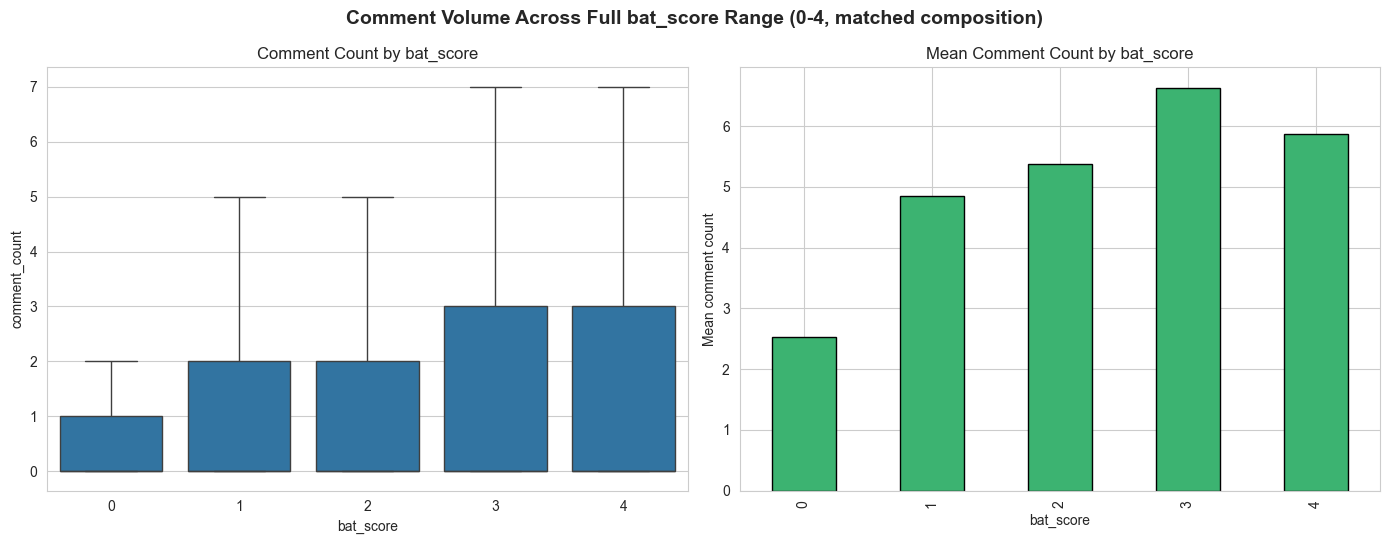

In [3]:
"""
FULL bat_score 0-4 TREND ANALYSIS (using matched comparison data)
=====================================================================
Combines the matched bat_score=0 sample with bat_score 1-4 posts
(already built in zero_comment_rate_comparison.csv) to test the full
dose-response trend, AND compares two competing explanations:

    GRADIENT model: comment_count ~ bat_score (continuous 0-4)
        "more severity -> proportionally more engagement"

    STEP model:     comment_count ~ is_burnout_flagged (0 vs 1+)
        "any burnout signal pulls more engagement, but degree
         within 1-4 doesn't matter"

Whichever model fits better (lower AIC/BIC) tells you which story
the data actually supports.

Reads:
    zero_comment_rate_comparison.csv   (post_id, comment_count — matched, 24,474 rows)
    bat_score_pos.csv                   (post_id, bat_score 1-4 — to recover real severity)
    bat0_comparison_sample.csv          (post_id, bat_score=0)

Writes:
    batscore_0to4_trend_summary.csv
    batscore_0to4_trend.png
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = '/Users/nadia/Desktop/redditRun_june/comment_data/'
INPUT_FILE = DATA_DIR + 'zero_comment_rate_comparison.csv'
BAT_POS_FILE = DATA_DIR + 'bat_score_pos.csv'
BAT0_SAMPLE_FILE = DATA_DIR + 'bat0_comparison_sample.csv'
OUTPUT_DIR = DATA_DIR

sns.set_style("whitegrid")


def load_data():
    # zero_comment_rate_comparison.csv only has a text 'group' label
    # ("bat_score>0" / "bat_score=0 (matched)"), not the actual numeric
    # bat_score (1-4 for positive posts collapsed into one string).
    # Reconstruct the real bat_score by merging back from the source files.
    df = pd.read_csv(INPUT_FILE, usecols=['post_id', 'comment_count', 'has_zero_comments'])
    df['post_id'] = df['post_id'].astype(str)

    pos = pd.read_csv(BAT_POS_FILE, usecols=['post_id', 'bat_score'])
    pos['post_id'] = pos['post_id'].astype(str)

    zero = pd.read_csv(BAT0_SAMPLE_FILE, usecols=['post_id', 'bat_score'])
    zero['post_id'] = zero['post_id'].astype(str)

    bat_lookup = pd.concat([pos, zero], ignore_index=True).drop_duplicates(subset='post_id')

    df = df.merge(bat_lookup, on='post_id', how='left')
    n_missing = df['bat_score'].isna().sum()
    if n_missing > 0:
        print(f"⚠ {n_missing:,} posts couldn't be matched back to a bat_score — dropping")
        df = df.dropna(subset=['bat_score'])
    df['bat_score'] = df['bat_score'].astype(int)

    df['is_burnout_flagged'] = (df['bat_score'] > 0).astype(int)
    print(f"Loaded {len(df):,} posts (bat_score 0-4, matched composition)")
    print(df.groupby('bat_score').agg(
        n_posts=('post_id', 'count'),
        mean_comment_count=('comment_count', 'mean'),
        pct_zero=('has_zero_comments', 'mean')
    ).round(3))
    return df


def trend_tests(df):
    print("\n" + "─" * 60)
    print("TREND TESTS: comment_count vs bat_score (0-4)")
    print("─" * 60)

    rho, p = stats.spearmanr(df['bat_score'], df['comment_count'])
    print(f"Spearman (bat_score vs comment_count): rho={rho:.4f}, p={p:.4g}")

    groups = [df.loc[df['bat_score'] == s, 'comment_count'] for s in sorted(df['bat_score'].unique())]
    h, p_kw = stats.kruskal(*groups)
    print(f"Kruskal-Wallis (comment_count across all 5 bat_score groups): H={h:.3f}, p={p_kw:.4g}")


def gradient_vs_step_model(df):
    print("\n" + "─" * 60)
    print("MODEL COMPARISON: GRADIENT vs STEP")
    print("─" * 60)

    # GRADIENT: bat_score as continuous 0-4
    gradient = smf.glm('comment_count ~ bat_score', data=df,
                        family=sm.families.NegativeBinomial()).fit()
    print(f"\nGRADIENT model (bat_score continuous):")
    print(f"  AIC={gradient.aic:.1f}  BIC={gradient.bic:.1f}  "
          f"coef(bat_score)={gradient.params['bat_score']:.4f}  p={gradient.pvalues['bat_score']:.4g}")

    # STEP: only whether flagged at all (0 vs 1+)
    step = smf.glm('comment_count ~ is_burnout_flagged', data=df,
                    family=sm.families.NegativeBinomial()).fit()
    print(f"\nSTEP model (0 vs 1+ only):")
    print(f"  AIC={step.aic:.1f}  BIC={step.bic:.1f}  "
          f"coef(is_burnout_flagged)={step.params['is_burnout_flagged']:.4f}  "
          f"p={step.pvalues['is_burnout_flagged']:.4g}")

    # COMBINED: both terms — does bat_score add anything beyond the 0/1+ split?
    combined = smf.glm('comment_count ~ is_burnout_flagged + bat_score', data=df,
                        family=sm.families.NegativeBinomial()).fit()
    print(f"\nCOMBINED model (both terms, tests whether severity matters BEYOND flagged/not):")
    print(combined.summary())

    print("\n" + "─" * 60)
    print("INTERPRETATION")
    print("─" * 60)
    better = 'GRADIENT' if gradient.aic < step.aic else 'STEP'
    print(f"Lower AIC = better fit: {better} model fits better "
          f"(gradient AIC={gradient.aic:.1f} vs step AIC={step.aic:.1f})")
    print("If GRADIENT wins clearly: engagement scales with severity, dose-response.")
    print("If STEP wins clearly: any burnout signal matters, but degree within it doesn't.")
    print("If COMBINED model's bat_score term is non-significant once is_burnout_flagged")
    print("is included: supports STEP interpretation (severity adds nothing beyond flagged/not).")

    return gradient, step, combined


def make_figure(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle('Comment Volume Across Full bat_score Range (0-4, matched composition)',
                  fontsize=14, fontweight='bold')

    sns.boxplot(data=df, x='bat_score', y='comment_count', ax=axes[0], showfliers=False)
    axes[0].set_title('Comment Count by bat_score')

    means = df.groupby('bat_score')['comment_count'].mean()
    means.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
    axes[1].set_title('Mean Comment Count by bat_score')
    axes[1].set_ylabel('Mean comment count')

    plt.tight_layout()
    out_path = OUTPUT_DIR + 'batscore_0to4_trend.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"\n✓ Figure saved: {out_path}")


if __name__ == '__main__':
    print("=" * 80)
    print("FULL bat_score 0-4 TREND ANALYSIS")
    print("=" * 80)

    df = load_data()
    trend_tests(df)
    gradient, step, combined = gradient_vs_step_model(df)
    make_figure(df)

    summary = df.groupby('bat_score').agg(
        n_posts=('post_id', 'count'),
        mean_comment_count=('comment_count', 'mean'),
        median_comment_count=('comment_count', 'median'),
        pct_zero=('has_zero_comments', 'mean'),
    ).reset_index()
    summary.to_csv(OUTPUT_DIR + 'batscore_0to4_trend_summary.csv', index=False)
    print(f"\n✓ batscore_0to4_trend_summary.csv saved")